[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train RF-DETR Object Detection on a Custom Dataset

---

[![hf space](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Spaces-blue)](https://huggingface.co/spaces/SkalskiP/RF-DETR)
[![colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/how-to-finetune-rf-detr-on-detection-dataset.ipynb)
[![roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/rf-detr)
[![code](https://badges.aleen42.com/src/github.svg)](https://github.com/roboflow/rf-detr)

RF-DETR is a real-time, transformer-based object detection model architecture developed by Roboflow and released under the Apache 2.0 license.

![rf-detr-coco-rf100-vl-8](https://media.roboflow.com/rfdetr/pareto.png)

The RF-DETR family of models stands as the quickest and most precise in object detection across all sizes. RF-DETR has achieved over 60 mAP on the Microsoft COCO benchmark, a leading measure of object detection performance. It also sets new records on RF100-VL, a benchmark that shows how well models adapt to real-world problems beyond standard datasets.

The RF-DETR model group includes five sizes: Nano, Small, Medium, Base, and Large. These models offer a range of options for different needs. For example, RF-DETR-Nano is 11 mAP higher than YOLO11-n (on mAP50:95) and runs 0.17 ms faster. Likewise, RF-DETR-Small is 1.8 mAP better than YOLO11-x (the biggest YOLO11 model) and speeds things up by a good 7.77 ms. This wide range of models makes RF-DETR a great choice for many real-world uses, from small devices that need to be super fast to bigger jobs that demand top precision.

RF-DETR is small enough to run on edge devices, making it perfect for deployments that need both high accuracy and real-time performance. You can easily get started with any of the RF-DETR models, as they're ready for training in the cloud with Roboflow or through the free RF-DETR Python package.

## Environment setup

### Configure API Key

To fine-tune RF-DETR, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy` to copy your private API key.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store your Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Check GPU availability

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Nov 24 00:37:15 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.14                 Driver Version: 566.14         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   52C    P8             N/A /  115W |    1487MiB /   8188MiB |     22%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Download example data

Downloads example images for testing. You can use these or replace them with your own images.

In [4]:
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg

## Inference with Pre-trained COCO Model

Runs inference on an example image using a pretrained RF-DETR Medium model (trained on COCO). To use a different model size, simply replace `RFDETRMedium` with `RFDETRNano`, `RFDETRSmall`, `RFDETRBase` or `RFDETRLarge` as needed.

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


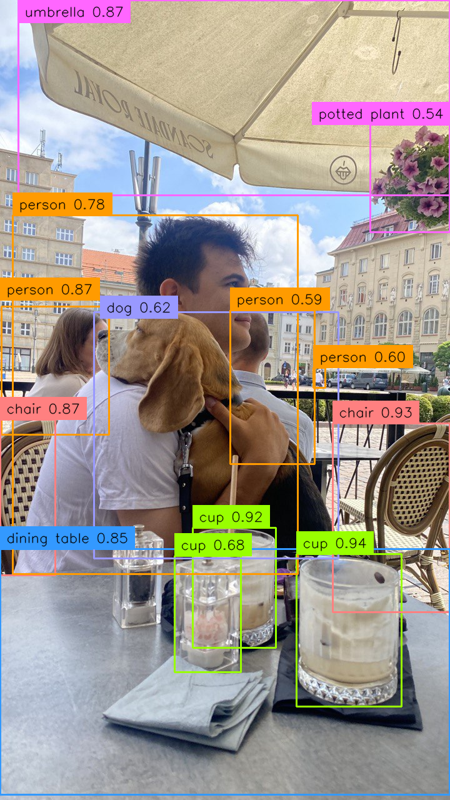

In [2]:
import numpy as np
import supervision as sv

from PIL import Image

from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES

image = Image.open("dog-2.jpeg")

model = RFDETRMedium(resolution=640)
model.optimize_for_inference()

detections = model.predict(image, threshold=0.5)

color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

labels = [
    f"{COCO_CLASSES[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotated_image = image.copy()
annotated_image = bbox_annotator.annotate(annotated_image, detections)
annotated_image = label_annotator.annotate(annotated_image, detections, labels)
annotated_image.thumbnail((800, 800))
annotated_image

In [ ]:
import supervision as sv
from rfdetr import RFDETRNano
from rfdetr.util.coco_classes import COCO_CLASSES

SOURCE_VIDEO_PATH = "video/vehicle-counting.mp4"
TARGET_VIDEO_PATH = "output/output_video/vehicle-counting_output.mp4"

model = RFDETRNano()
model.optimize_for_inference()

def callback(frame, index):
    detections = model.predict(frame[:, :, ::-1], threshold=0.5)

    labels = [
        f"{COCO_CLASSES[class_id]} {confidence:.2f}"
        for class_id, confidence
        in zip(detections.class_id, detections.confidence)
    ]

    annotated_frame = frame.copy()
    annotated_frame = sv.BoxAnnotator().annotate(annotated_frame, detections)
    annotated_frame = sv.LabelAnnotator().annotate(annotated_frame, detections, labels)
    return annotated_frame

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback
)

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [ ]:
import cv2
import supervision as sv
from rfdetr import RFDETRMedium
from rfdetr.util.coco_classes import COCO_CLASSES
from PIL import Image

# --- Configuration ---
SOURCE_VIDEO_PATH = "night1.mp4"
TARGET_VIDEO_PATH = "output_night1.mp4"
CONFIDENCE_THRESHOLD = 0.5
# ---------------------

print("Loading RF-DETR Medium model (pre-trained on COCO)...")
# Load the pre-trained RF-DETR Medium model
model = RFDETRMedium(weights="coco")
# Optimize the model for faster inference
model.optimize_for_inference()
print("Model loaded successfully.")

# Initialize supervision annotators
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])
text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True
)

print(f"Opening video file: {SOURCE_VIDEO_PATH}")
# Open the source video file
cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)

# Get video properties (width, height, fps)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Create a video writer to save the output
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(TARGET_VIDEO_PATH, fourcc, fps, (width, height))

print(f"Processing video and saving to: {TARGET_VIDEO_PATH}")
frame_count = 0
while cap.isOpened():
    # Read a frame from the video
    success, frame = cap.read()
    if not success:
        # End of video
        break

    # 1. Convert frame for model
    # OpenCV uses BGR, but RF-DETR (like most models) expects RGB.
    # We also convert it to a PIL Image, which the .predict() method expects.
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(rgb_frame)

    # 2. Run Inference
    # The .predict() method returns a supervision.Detections object
    detections = model.predict(pil_image, threshold=CONFIDENCE_THRESHOLD)
    
    # 3. Create labels
    labels = [
        f"{COCO_CLASSES[class_id]} {confidence:.2f}"
        for class_id, confidence 
        in zip(detections.class_id, detections.confidence)
    ]

    # 4. Annotate the original frame (BGR)
    annotated_frame = bbox_annotator.annotate(
        scene=frame.copy(), 
        detections=detections
    )
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame, 
        detections=detections, 
        labels=labels
    )

    # 5. Write the annotated frame to the output video
    writer.write(annotated_frame)
    
    frame_count += 1
    if frame_count % 30 == 0: # Print progress every 30 frames
        print(f"Processed {frame_count} frames...")

    # (Optional) Display the output in a window
    # cv2.imshow("RF-DETR Inference", annotated_frame)
    # if cv2.waitKey(1) & 0xFF == ord('q'):
    #    break

# --- Cleanup ---
cap.release()
writer.release()
cv2.destroyAllWindows()
print(f"Done! Processed {frame_count} frames. Output saved to {TARGET_VIDEO_PATH}")

## Download Dataset from Roboflow Universe

RF-DETR expects the dataset to be in COCO format. Divide your dataset into three subdirectories: `train`, `valid`, and `test`. Each subdirectory should contain its own `_annotations.coco.json` file that holds the annotations for that particular split, along with the corresponding image files. Below is an example of the directory structure:

```
dataset/
├── train/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
├── valid/
│   ├── _annotations.coco.json
│   ├── image1.jpg
│   ├── image2.jpg
│   └── ... (other image files)
└── test/
    ├── _annotations.coco.json
    ├── image1.jpg
    ├── image2.jpg
    └── ... (other image files)
```

[Roboflow](https://roboflow.com/annotate) allows you to create object detection datasets from scratch or convert existing datasets from formats like YOLO, and then export them in COCO JSON format for training. You can also explore [Roboflow Universe](https://universe.roboflow.com/) to find pre-labeled datasets for a range of use cases.

In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="sjKAVuO8Lkaq5h2dDfDA")
project = rf.workspace("fyp-vfrgn").project("veiculos-contar-dnosk")
version = project.version(3)
dataset = version.download("coco")
                

loading Roboflow workspace...
loading Roboflow project...
Exporting format coco in progress : 85.0%
Version export complete for coco format



Extracting Dataset Version Zip to Veiculos-Contar-3 in coco:: 100%|██████████| 7282/7282 [00:04<00:00, 1555.73it/s]


## Train RF-DETR on custom dataset

### Choose the right `batch_size`

Different GPUs have different amounts of VRAM (video memory), which limits how much data they can handle at once during training. To make training work well on any machine, you can adjust two settings: `batch_size` and `grad_accum_steps`. These control how many samples are processed at a time. The key is to keep their product equal to 16 — that’s our recommended total batch size. For example, on powerful GPUs like the A100, set `batch_size=16` and `grad_accum_steps=1`. On smaller GPUs like the T4, use `batch_size=4` and `grad_accum_steps=4`. We use a method called gradient accumulation, which lets the model simulate training with a larger batch size by gradually collecting updates before adjusting the weights.

In [3]:
import torch
print(torch.cuda.is_available())
print(torch.version.cuda)
print(torch.cuda.device_count())

True
12.6
1


In [9]:
# from rfdetr import RFDETRMedium

# model = RFDETRMedium()

# model.train(dataset_dir=dataset.location, epochs=10, batch_size=4, grad_accum_steps=4)
from rfdetr import RFDETRBase

model = RFDETRBase()
history = []

def callback2(data):
	history.append(data)

model.callbacks["on_fit_epoch_end"].append(callback2)

model.train(
    dataset_dir=dataset.location, 
    epochs=30, 
    batch_size=4, 
    grad_accum_steps=4,  # Effective batch size = 16
    lr=1e-4,  # Or try 1e-5 if 1e-4 seems unstable
    weight_decay=1e-4
)

Loading pretrain weights


num_classes mismatch: model has 90 classes, but your dataset has 8 classes
reinitializing your detection head with 8 classes.


Unable to initialize TensorBoard. Logging is turned off for this session.  Run 'pip install tensorboard' to enable logging.
Not using distributed mode
git:
  sha: 016f892af6ef9d0ac6576415bda4808d132b715b, status: has uncommited changes, branch: main

Namespace(num_classes=8, grad_accum_steps=4, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=30, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-base.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[2, 5, 8, 11], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=3, dim_feedfor

Epoch: [0]  [  0/345]  eta: 1:27:56  lr: 0.000100  class_error: 99.00  loss: 10.1060 (10.1060)  loss_ce: 0.9121 (0.9121)  loss_bbox: 0.5421 (0.5421)  loss_giou: 1.0188 (1.0188)  loss_ce_0: 0.8566 (0.8566)  loss_bbox_0: 0.6255 (0.6255)  loss_giou_0: 1.1077 (1.1077)  loss_ce_1: 0.9114 (0.9114)  loss_bbox_1: 0.5510 (0.5510)  loss_giou_1: 1.0189 (1.0189)  loss_ce_enc: 0.8777 (0.8777)  loss_bbox_enc: 0.5951 (0.5951)  loss_giou_enc: 1.0891 (1.0891)  loss_ce_unscaled: 0.9121 (0.9121)  class_error_unscaled: 98.9967 (98.9967)  loss_bbox_unscaled: 0.1084 (0.1084)  loss_giou_unscaled: 0.5094 (0.5094)  cardinality_error_unscaled: 3893.7500 (3893.7500)  loss_ce_0_unscaled: 0.8566 (0.8566)  loss_bbox_0_unscaled: 0.1251 (0.1251)  loss_giou_0_unscaled: 0.5538 (0.5538)  cardinality_error_0_unscaled: 3614.2500 (3614.2500)  loss_ce_1_unscaled: 0.9114 (0.9114)  loss_bbox_1_unscaled: 0.1102 (0.1102)  loss_giou_1_unscaled: 0.5094 (0.5094)  cardinality_error_1_unscaled: 3879.7500 (3879.7500)  loss_ce_enc_uns

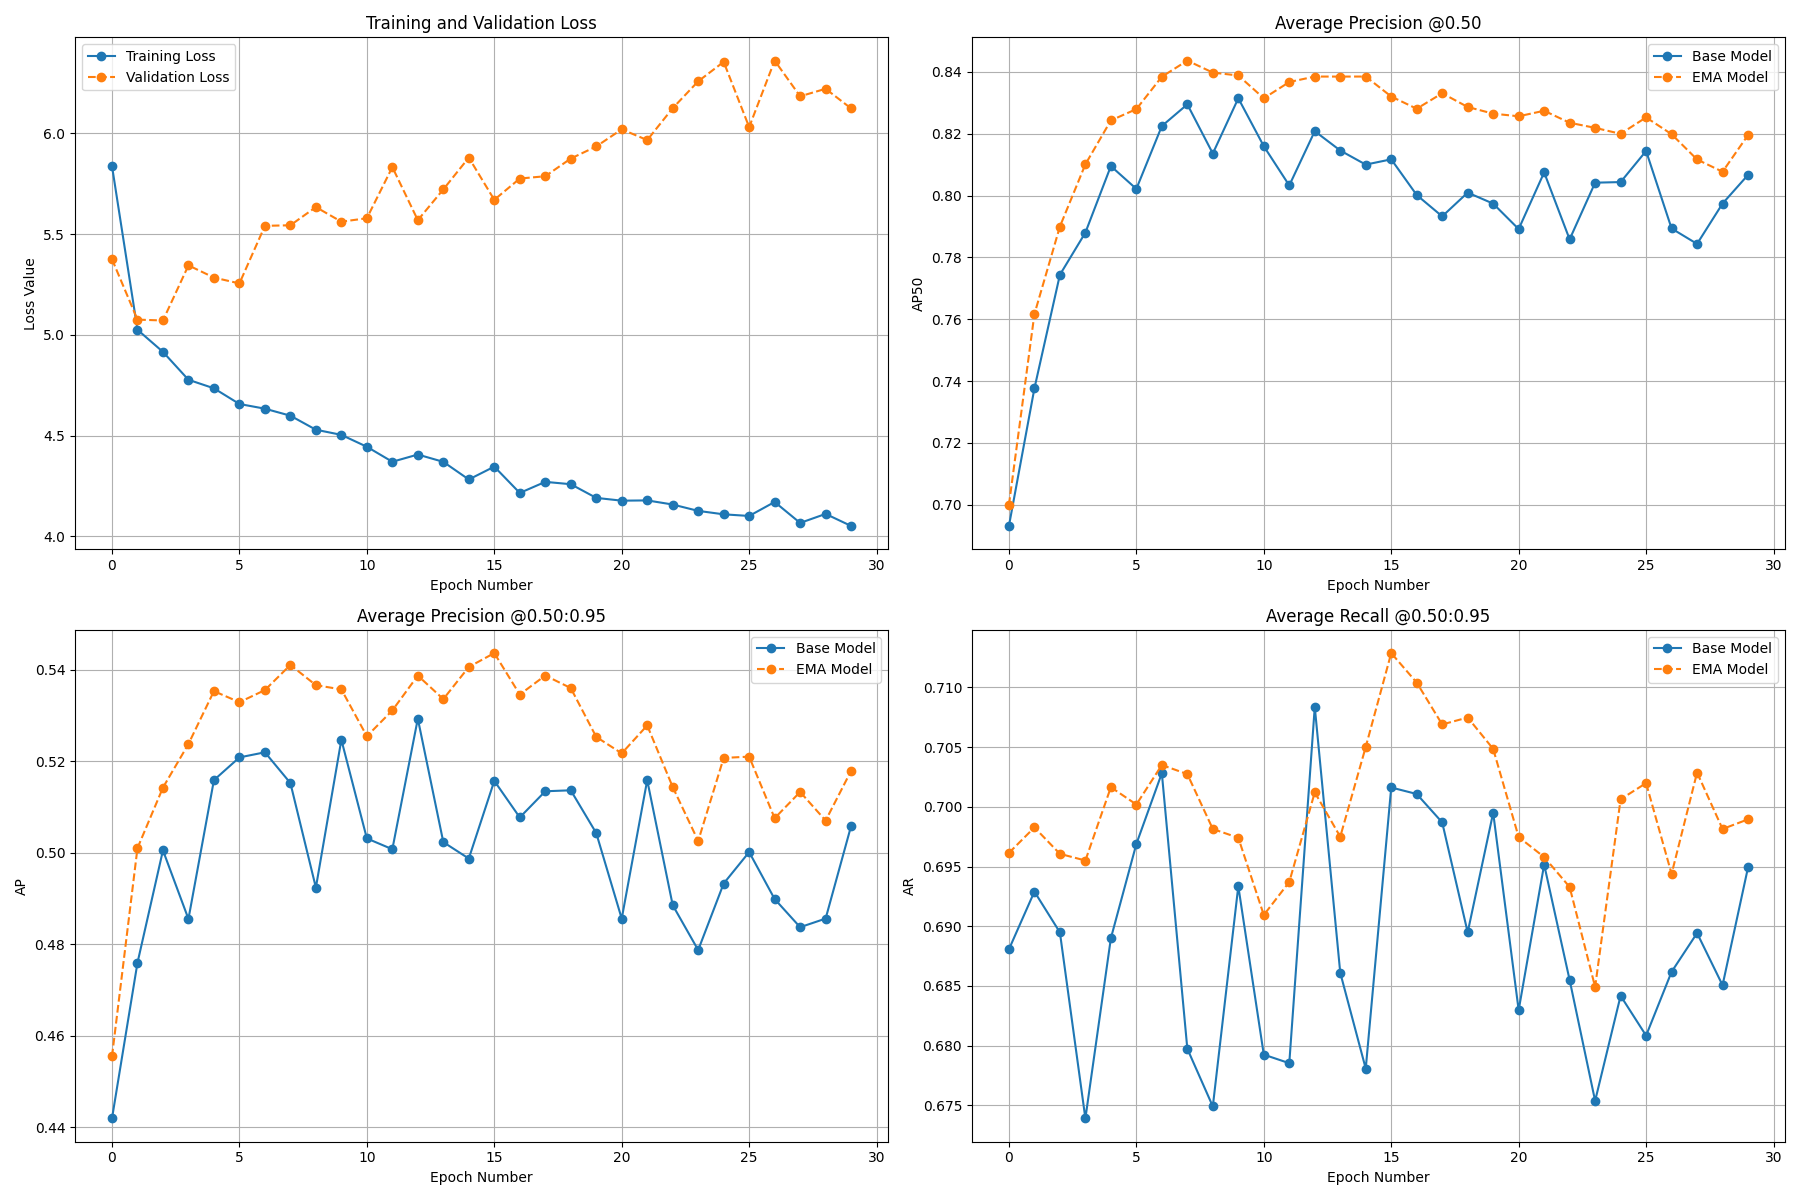

In [10]:
from PIL import Image

Image.open("output/metrics_plot.png")

In [15]:
ls -la output

 Volume in drive C has no label.
 Volume Serial Number is 20BB-771E

 Directory of c:\Users\user\Documents\Vehicle-Detection-at-R-R-\notebooks


 Directory of c:\Users\user\Documents\Vehicle-Detection-at-R-R-\notebooks\output

04/11/2025  01:22 AM    <DIR>          .
04/11/2025  12:48 AM    <DIR>          ..
04/11/2025  01:19 AM       483,833,933 checkpoint.pth
04/11/2025  01:21 AM       362,914,282 checkpoint_best_ema.pth
04/11/2025  12:57 AM       362,921,798 checkpoint_best_regular.pth
04/11/2025  01:21 AM       120,941,407 checkpoint_best_total.pth
04/11/2025  12:50 AM    <DIR>          eval
04/11/2025  01:21 AM            39,060 log.txt
04/11/2025  01:22 AM           160,393 metrics_plot.png
04/11/2025  01:22 AM             3,575 results.json
               7 File(s)  1,330,814,448 bytes
               3 Dir(s)  342,621,671,424 bytes free


File Not Found


## Deploy a Trained RF-DETR Model

Deploying to Roboflow allows you to create multi-step computer vision applications that run both in the cloud and your own hardware. Please wait a moment while Roboflow indexes your model.

In [ ]:
model.deploy_to_roboflow(
  workspace="fyp-vfrgn",
  project_id="veiculos-contar-dnosk",
  version=3,
  api_key="sjKAVuO8Lkaq5h2dDfDA"
)

NameError: name 'model' is not defined

## Evaluate Fine-tuned RF-DETR Model

Before benchmarking the model, we need to load the best saved checkpoint. To ensure it fits on the GPU, we first need to free up GPU memory. This involves deleting any remaining references to previously used objects, triggering Python’s garbage collector, and clearing the CUDA memory cache.

In [11]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [12]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 139.55 MB | Reserved: 6390.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 139.55 MB | Reserved: 282.00 MB


We load the best-performing model from the `checkpoint_best_total.pth` file using the `RFDETRMedium` class. This checkpoint contains the trained weights from our most successful training run. After loading, we call `optimize_for_inference()`, which prepares the model for efficient inference.

In [1]:
from rfdetr import RFDETRBase
model = RFDETRBase(pretrain_weights="output/checkpoint_best_total.pth")
model.optimize_for_inference()

Loading pretrain weights


num_classes mismatch: pretrain weights has 7 classes, but your model has 90 classes
reinitializing detection head with 7 classes
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


In [ ]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

In [15]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 290/290 [00:10<00:00, 28.74it/s]


In [16]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.525
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.822
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.628
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.246
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.556
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.649


## get_model

In [ ]:
# !pip install -q inference-gpu==0.51.7
from inference import get_model

MODEL_ID = "basketball-player-detection-2/13"
model_rf = get_model(model_id=MODEL_ID, api_key="sjKAVuO8Lkaq5h2dDfDA")
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

result = model_rf.infer(image, confidence=0.3)[0]
detections = sv.Detections.from_inference(result)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

## ⭐ Run Inference with Fine-tuned RF-DETR Model

### 0. Dataset & Model Variables Setup

In [2]:
from roboflow import Roboflow
from rfdetr import RFDETRBase
import supervision as sv
rf = Roboflow(api_key="sjKAVuO8Lkaq5h2dDfDA")
project = rf.workspace("fyp-vfrgn").project("veiculos-contar-dnosk")
version = project.version(3)
dataset = version.download("coco")

model = RFDETRBase(pretrain_weights="output/checkpoint_best_total.pth")
model.optimize_for_inference()

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

loading Roboflow workspace...
loading Roboflow project...


num_classes mismatch: pretrain weights has 7 classes, but your model has 90 classes
reinitializing detection head with 7 classes


Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


## 1. Image Inference

### 1.1 on test set

In [ ]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[119]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

### 1.2 without resizing

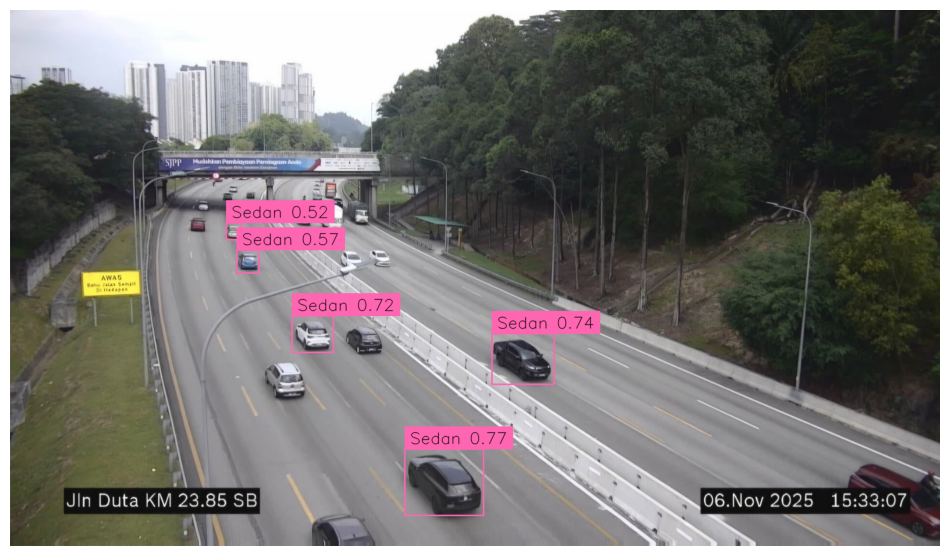

In [11]:
import supervision as sv
from PIL import Image

path = "image/jln_duta_4.jpg"
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080", "#b266ff"
])

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_image(detections_image)

### 1.3 with resizing

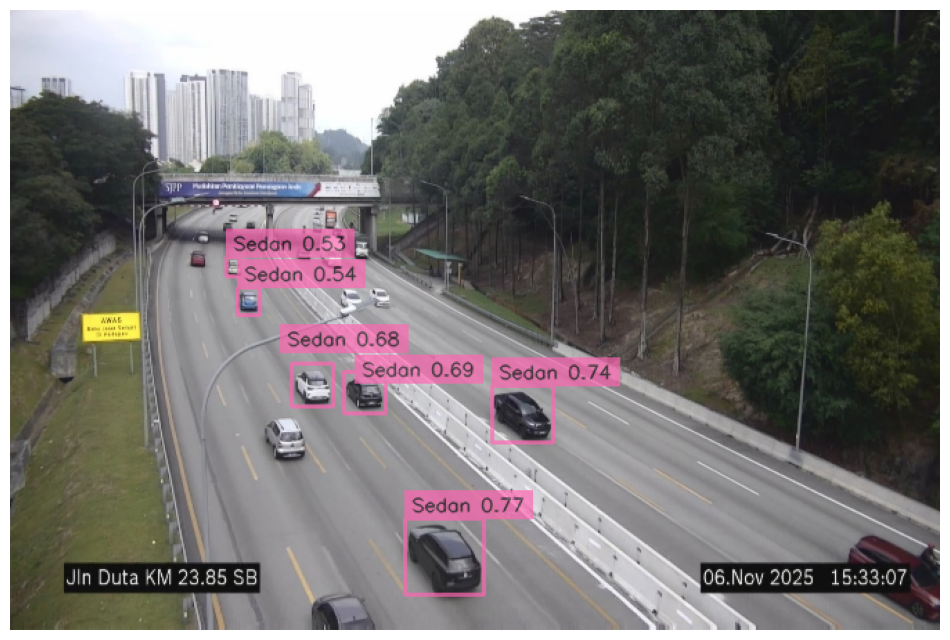

Output image saved to: output/output_image\jln_duta_4_output.jpg


In [10]:
import os
import cv2
import numpy as np
import supervision as sv
from PIL import Image

path = "image/jln_duta_4.jpg"
image = Image.open(path)

target_size = (672, 448)  # (width, height)
# Convert PIL Image to numpy array for cv2.resize
image_np = np.array(image)
image_frame = cv2.resize(image_np, target_size, interpolation=cv2.INTER_LINEAR)
# Convert back to PIL Image for model prediction
image_frame = Image.fromarray(image_frame)

detections = model.predict(image_frame, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image_frame.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image_frame.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080", "#b266ff"
])

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True,
    text_padding=5
    )

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

detections_image = image_frame.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

# Apply transparency manually
if isinstance(detections_image, Image.Image):
    detections_image_np = np.array(detections_image)
else:
    detections_image_np = detections_image

if isinstance(image_frame, Image.Image):
    image_frame_np = np.array(image_frame)
else:
    image_frame_np = image_frame

# Blend annotated image with original (0.7 = 70% annotated, 0.3 = 30% original)
alpha = 0.7  # Adjust this value: 0.5 = 50% transparent, 0.8 = 20% transparent
detections_image_blended = cv2.addWeighted(detections_image_np, alpha, image_frame_np, 1 - alpha, 0)
detections_image = Image.fromarray(detections_image_blended)

sv.plot_image(detections_image)


output_dir = "output/output_image"
os.makedirs(output_dir, exist_ok=True)
original_filename = os.path.splitext(os.path.basename(path))[0]
output_filename = f"{original_filename}_output.jpg"
output_path = os.path.join(output_dir, output_filename)

# Convert PIL Image to numpy array if needed for cv2
if isinstance(detections_image, Image.Image):
    detections_image_np = cv2.cvtColor(np.array(detections_image), cv2.COLOR_RGB2BGR)
else:
    detections_image_np = detections_image

# Save the image
cv2.imwrite(output_path, detections_image_np)
print(f"Output image saved to: {output_path}")

## 2. Video Inference

### Setup

In [3]:
# Video inference with the fine-tuned RF-DETR model
import cv2
import os
from pathlib import Path
from PIL import Image

NUM_CLASSES = len(ds.classes)
class_names = ds.classes
SOURCE_VIDEO_PATH = "video/traffic3_cropped.mp4"
CONFIDENCE_THRESHOLD = 0.5

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Unable to open video: {SOURCE_VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
width = 672
height = 448
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
resolution_wh = (width, height)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080", "#b266ff"
])

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True,
    text_padding=5
    )

output_dir = "output/output_video"
os.makedirs(output_dir, exist_ok=True)
original_filename = os.path.splitext(os.path.basename(SOURCE_VIDEO_PATH))[0]
output_filename = f"{original_filename}_output.mp4"
output_path = os.path.join(output_dir, output_filename)

writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

### 2.1 only resizing

In [3]:
frame_idx = 0
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        target_size = (width, height)   # (width, height)
        resized_frame = cv2.resize(frame, target_size, interpolation=cv2.INTER_LINEAR)


        rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        detections = model.predict(pil_image, threshold=CONFIDENCE_THRESHOLD)

        labels = [
            f"{class_names[class_id]} {confidence:.2f}"
            for class_id, confidence in zip(detections.class_id, detections.confidence)
        ]

        annotated_frame = bbox_annotator.annotate(scene=resized_frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels,
        )

        writer.write(annotated_frame)

        frame_idx += 1
        if frame_idx % 50 == 0:
            print(f"Processed {frame_idx} frames...")
        
        cv2.imshow("RF-DETR Inference", annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
           break
finally:
    cap.release()
    writer.release()
    cv2.destroyAllWindows()

print(f"Inference complete. Saved annotated video to {output_path}")


Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
Processed 500 frames...
Processed 550 frames...
Processed 600 frames...
Processed 650 frames...
Processed 700 frames...
Processed 750 frames...
Processed 800 frames...
Processed 850 frames...
Processed 900 frames...
Processed 950 frames...
Processed 1000 frames...
Processed 1050 frames...
Processed 1100 frames...
Processed 1150 frames...
Processed 1200 frames...
Processed 1250 frames...
Processed 1300 frames...
Processed 1350 frames...
Processed 1400 frames...
Processed 1450 frames...
Processed 1500 frames...
Processed 1550 frames...
Processed 1600 frames...
Processed 1650 frames...
Processed 1700 frames...
Processed 1750 frames...
Processed 1800 frames...
Inference complete. Saved annotated video to output/output_video\traffic3_cropped_output.mp4


### 2.2 other image preprocessing techniques

In [6]:
def handle_weather_conditions(frame):
    # Dehazing for foggy/hazy conditions
    def dehaze(img):
        # Simple dark channel prior-based dehazing
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        dark_channel = np.min(img, axis=2)
        dark_channel = cv2.morphologyEx(dark_channel, cv2.MORPH_CLOSE, kernel)
        
        # Estimate atmospheric light
        flat = dark_channel.flatten()
        num_pixels = len(flat)
        top_pixels = int(num_pixels * 0.001)
        indices = np.argpartition(flat, -top_pixels)[-top_pixels:]
        
        atmospheric_light = np.max(img.reshape(-1, 3)[indices], axis=0)
        
        # Transmission map
        transmission = 1 - 0.95 * (dark_channel / np.max(atmospheric_light))
        transmission = np.maximum(transmission, 0.1)
        
        # Recover scene
        dehazed = np.zeros_like(img, dtype=np.float32)
        for c in range(3):
            dehazed[:,:,c] = ((img[:,:,c].astype(np.float32) - atmospheric_light[c]) / 
                              transmission + atmospheric_light[c])
        
        return np.clip(dehazed, 0, 255).astype(np.uint8)
    
    return dehaze(frame)

In [ ]:
class VideoPreprocessor:
    def __init__(self, enable_clahe=True, enable_denoise=True, 
                 enable_dehaze=False, enable_motion_reduction=False):
        self.enable_clahe = enable_clahe
        self.enable_denoise = enable_denoise
        self.enable_dehaze = enable_dehaze
        self.enable_motion_reduction = enable_motion_reduction
        self.prev_frame = None
    
    def process_frame(self, frame):
        processed = frame.copy()
        
        # Step 1: Denoise if enabled
        if self.enable_denoise:
            processed = cv2.bilateralFilter(processed, d=5, sigmaColor=50, sigmaSpace=50)
        
        # Step 2: Enhance illumination
        if self.enable_clahe:
            lab = cv2.cvtColor(processed, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
            l = clahe.apply(l)
            processed = cv2.merge([l, a, b])
            processed = cv2.cvtColor(processed, cv2.COLOR_LAB2BGR)
        
        # Step 3: Dehaze if needed (for foggy conditions)
        if self.enable_dehaze:
            processed = handle_weather_conditions(processed)
        
        # Step 4: Motion blur reduction
        if self.enable_motion_reduction and self.prev_frame is not None:
            processed = cv2.addWeighted(processed, 0.7, self.prev_frame, 0.3, 0)
        
        self.prev_frame = processed.copy()
        return processed

# Modified video inference code
preprocessor = VideoPreprocessor(
    enable_clahe=True,
    enable_denoise=True,
    enable_dehaze=False,  # Enable if video has fog/haze
    enable_motion_reduction=False  # Enable for high-speed traffic
)

frame_idx = 0
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Apply preprocessing
        processed_frame = preprocessor.process_frame(frame)
        
        # Convert to RGB for model
        rgb_frame = cv2.cvtColor(processed_frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        detections = model.predict(pil_image, threshold=CONFIDENCE_THRESHOLD)
        
        # Rest of your annotation code...
        labels = [
            f"{class_names[class_id]} {confidence:.2f}"
            for class_id, confidence in zip(detections.class_id, detections.confidence)
        ]
        
        # Annotate on the processed frame for better visibility
        annotated_frame = bbox_annotator.annotate(scene=processed_frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels,
        )
        
        writer.write(annotated_frame)
        
        frame_idx += 1
        if frame_idx % 50 == 0:
            print(f"Processed {frame_idx} frames...")
finally:
    cap.release()
    writer.release()

Processed 50 frames...
Processed 100 frames...
Processed 150 frames...
Processed 200 frames...
Processed 250 frames...
Processed 300 frames...
Processed 350 frames...
Processed 400 frames...
Processed 450 frames...
Processed 500 frames...
Processed 550 frames...
Processed 600 frames...


## 3. Vehicle Counting

In [16]:
import cv2
import os
from pathlib import Path
from PIL import Image
import supervision as sv
import math

# --- Setup ---
SOURCE_VIDEO_PATH = "video/traffic3_cropped.mp4"
CONFIDENCE_THRESHOLD = 0.5
width, height = 672, 448

# Use your dataset class names
class_names = ds.classes

cap = cv2.VideoCapture(SOURCE_VIDEO_PATH)
fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

output_dir = "output/output_video"
os.makedirs(output_dir, exist_ok=True)
original_filename = os.path.splitext(os.path.basename(SOURCE_VIDEO_PATH))[0]
output_filename = f"{original_filename}_counted.mp4"
output_path = os.path.join(output_dir, output_filename)
writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# --- Line drawing ---
line_points = []

def draw_line(event, x, y, flags, param):
    global line_points

    base = param.copy()

    if event == cv2.EVENT_LBUTTONDOWN:
        # Start point (on mouse press)
        line_points = [(x, y)]

    elif event == cv2.EVENT_MOUSEMOVE and len(line_points) == 1:
        # Preview line while dragging
        cv2.line(base, line_points[0], (x, y), (0, 255, 0), 2)
        cv2.imshow("Define Line", base)
        return

    elif event == cv2.EVENT_LBUTTONUP and len(line_points) == 1:
        # End point (on mouse release)
        line_points.append((x, y))
        cv2.line(base, line_points[0], line_points[1], (0, 255, 0), 2)
        cv2.imshow("Define Line", base)
        return

    cv2.imshow("Define Line", base)

# Grab first frame for line definition
ret, first_frame = cap.read()
if not ret:
    raise RuntimeError("Unable to read video")
first_frame = cv2.resize(first_frame, (width, height))
cv2.imshow("Define Line", first_frame)
cv2.setMouseCallback("Define Line", draw_line, first_frame)
print("Draw a line by click-and-dragging on the frame window...")
cv2.waitKey(0)
cv2.destroyWindow("Define Line")

if len(line_points) != 2:
    raise RuntimeError("Line not defined. Please click and drag to draw a line.")

# --- Counting + tracking setup ---
vehicle_counts = {}     # {class_name: count}
tracks = {}             # track_id -> dict with state
next_track_id = 0

MAX_ASSOC_DIST = 40.0   # max distance (pixels) to associate detections to an existing track
MAX_MISSED_FRAMES = 20  # drop tracks not seen for this many frames
DIST_THRESHOLD = 20.0   # pixels band around line for crossing

# --- Annotators ---
resolution_wh = (width, height)
text_scale = sv.calculate_optimal_text_scale(resolution_wh=resolution_wh)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=resolution_wh)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080", "#b266ff"
])

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale,
    smart_position=True,
    text_padding=5
)

# --- Helper: signed distance to line (in pixels) ---
def line_signed_distance(p1, p2, centroid):
    x1, y1 = p1
    x2, y2 = p2
    cx, cy = centroid

    a = y2 - y1
    b = x1 - x2
    c = x2 * y1 - x1 * y2

    denom = math.hypot(a, b)
    if denom == 0:
        return 0.0
    return (a * cx + b * cy + c) / denom

# --- Main loop ---
frame_idx = 0
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)  # restart video
try:
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        resized_frame = cv2.resize(frame, (width, height))
        rgb_frame = cv2.cvtColor(resized_frame, cv2.COLOR_BGR2RGB)
        pil_image = Image.fromarray(rgb_frame)
        detections = model.predict(pil_image, threshold=CONFIDENCE_THRESHOLD)

        labels = [
            f"{class_names[class_id]} {confidence:.2f}"
            for class_id, confidence in zip(detections.class_id, detections.confidence)
        ]

        annotated_frame = bbox_annotator.annotate(scene=resized_frame.copy(), detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels,
        )

        # Draw counting line
        cv2.line(annotated_frame, line_points[0], line_points[1], (0, 255, 0), 2)

        # --- Simple centroid-based tracking ---
        # 1) Remove old tracks
        for tid in list(tracks.keys()):
            if frame_idx - tracks[tid]["last_frame"] > MAX_MISSED_FRAMES:
                del tracks[tid]

        # 2) Prepare detections centroids
        centroids = []
        for xyxy in detections.xyxy:
            cx = int((xyxy[0] + xyxy[2]) / 2)
            cy = int((xyxy[1] + xyxy[3]) / 2)
            centroids.append((cx, cy))

        det_to_track = [-1] * len(centroids)

        # 3) Associate detections to existing tracks (greedy nearest-neighbor)
        candidates = []
        for tid, t in tracks.items():
            for i, (cx, cy) in enumerate(centroids):
                d = math.hypot(cx - t["cx"], cy - t["cy"])
                if d < MAX_ASSOC_DIST:
                    candidates.append((d, tid, i))
        candidates.sort(key=lambda x: x[0])

        used_tracks = set()
        used_dets = set()
        for d, tid, i in candidates:
            if tid in used_tracks or i in used_dets:
                continue
            used_tracks.add(tid)
            used_dets.add(i)
            det_to_track[i] = tid
            t = tracks[tid]
            t["cx"], t["cy"] = centroids[i]
            t["class_id"] = int(detections.class_id[i])
            t["last_frame"] = frame_idx

        # 4) Create new tracks for unmatched detections
        for i, (cx, cy) in enumerate(centroids):
            if i in used_dets:
                continue
            tid = next_track_id
            next_track_id += 1
            tracks[tid] = {
                "cx": cx,
                "cy": cy,
                "class_id": int(detections.class_id[i]),
                "last_frame": frame_idx,
                "last_dist": None,
                "counted": False,
            }
            det_to_track[i] = tid

        # --- Counting: one count per track when it crosses the line ---
        for tid, t in tracks.items():
            cx, cy = t["cx"], t["cy"]
            dist = line_signed_distance(line_points[0], line_points[1], (cx, cy))
            prev = t["last_dist"]

            if prev is not None and not t["counted"]:
                # Check for side change and being close to line
                if prev * dist < 0 and min(abs(prev), abs(dist)) < DIST_THRESHOLD:
                    cls_name = class_names[t["class_id"]]
                    vehicle_counts[cls_name] = vehicle_counts.get(cls_name, 0) + 1
                    t["counted"] = True
                    print(f"{cls_name} crossed line. Total: {vehicle_counts[cls_name]}")

            t["last_dist"] = dist

            # (Optional) draw track points for debugging
            cv2.circle(annotated_frame, (int(cx), int(cy)), 2, (0, 255, 255), -1)

        # Overlay counts
        y_offset = 30
        for cls, count in vehicle_counts.items():
            cv2.putText(annotated_frame, f"{cls}: {count}", (10, y_offset),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
            y_offset += 30

        writer.write(annotated_frame)
        cv2.imshow("RF-DETR Counting", annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

        frame_idx += 1
finally:
    cap.release()
    writer.release()
    cv2.destroyAllWindows()

print("Final vehicle counts:", vehicle_counts)
print(f"Inference complete. Saved counted video to {output_path}")

Draw a line by click-and-dragging on the frame window...
Van crossed line. Total: 1
Pickup crossed line. Total: 1
Van crossed line. Total: 2
Sedan crossed line. Total: 1
Van crossed line. Total: 3
Van crossed line. Total: 4
Sedan crossed line. Total: 2
Sedan crossed line. Total: 3
Sedan crossed line. Total: 4
Suv crossed line. Total: 1
Van crossed line. Total: 5
Sedan crossed line. Total: 5
Suv crossed line. Total: 2
Sedan crossed line. Total: 6
Sedan crossed line. Total: 7
Sedan crossed line. Total: 8
Sedan crossed line. Total: 9
Sedan crossed line. Total: 10
Sedan crossed line. Total: 11
Sedan crossed line. Total: 12
Pickup crossed line. Total: 2
Suv crossed line. Total: 3
Sedan crossed line. Total: 13
Van crossed line. Total: 6
Sedan crossed line. Total: 14
Sedan crossed line. Total: 15
Van crossed line. Total: 7
Sedan crossed line. Total: 16
Suv crossed line. Total: 4
Sedan crossed line. Total: 17
Truck crossed line. Total: 1
Sedan crossed line. Total: 18
Sedan crossed line. Total: